In [1]:
#Ollama Setup
# 
# Step 1: system + Python deps
!pip -q install "mcp[cli]" fastapi uvicorn pytz requests nest_asyncio

# Step 2: install Ollama (Linux and Mac)
import platform
import subprocess
import shutil

system = platform.system()
if system == "Linux":
    curl_process = subprocess.Popen(["curl", "-fsSL", "https://ollama.com/install.sh"], stdout=subprocess.PIPE)
    subprocess.run(["sh"], stdin=curl_process.stdout, check=True)
    curl_process.wait()
elif system == "Darwin":  # macOS
    if not shutil.which("ollama"):
        if shutil.which("brew"):
            subprocess.run(["brew", "install", "ollama"], check=True)
        else:
            print("Homebrew not found. Please install Ollama manually from https://ollama.com/download")
    else:
        print("Ollama already installed")
else:
    print(f"Unsupported OS: {system}")

# Step 3: start Ollama server in background
import os
ollama_process = subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
    start_new_session=True
)
print("Ollama server started in background")

# Step 4: pull a tiny model so Colab doesn't choke
import time
time.sleep(5)  # Wait a bit for server to start
subprocess.run(["ollama", "pull", "llama3.2:3b"], check=True)


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Ollama already installed
Ollama server started in background


pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest 
pulling dde5aa3fc5ff: 100% ▕██████████████████▏ 2.0 GB                         
pulling 966de95ca8a6: 100% ▕██████████████████▏ 1.4 KB                         
pulling fcc5a6bec9da: 100% ▕██████████████████▏ 7.7 KB                         
pulling a70ff7e570d9: 100% ▕██████████████████▏ 6.0 KB                         
pulling 56bb8bd477a5: 100% ▕██████████████████▏   96 B                         
pulling 34bb5ab01051: 100% ▕██████████████████▏  561 B                         
verifying sha256 digest 
writing manifest 
success 


CompletedProcess(args=['ollama', 'pull', 'llama3.2:3b'], returncode=0)

In [2]:
COLLECTION_NAME = "reg_pos_facom"

In [3]:
OLLAMA_URL = '127.0.0.1:11434'
MODEL = "llama3.2:3b"

from ollama import Client
client_ollama = Client(
  host=OLLAMA_URL
)

In [4]:
def get_response(context: str):
  response = client_ollama.chat(model=MODEL, messages=[
    {
      'role': 'system',
      'content': "Você é um assistente de IA que responde perguntas sobre o regulamento da pós graduação da Faculdade de Computação da Universidade Federal de Mato Grosso do Sul - FACOM UFMS."
    },
    {
      'role': 'user',
      'content': context,
    },
  ])
  return response.message.content


In [5]:
import unicodedata
import pdfplumber
import re

def extract_text_from_pdf(pdf_path: str) -> str:
    pages_text = []
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text() or ""
            pages_text.append(text)
    full_text = "\n\n".join(pages_text)
    return full_text

def basic_cleanup(text: str) -> str:
    text = re.sub(r"N°\s*\d+", "", text)
    text = re.sub(r"Pg\.\s*\d+", "", text)
    text = re.sub(r"\d{2}/\d{2}/\d{4}", "", text)
    text = re.sub(r"BOLETIM.*?\n", "", text, flags=re.IGNORECASE)
    
    text = text.replace('\x00', 't')
    text = text.replace('\u0000', 't')
    
    nfd = unicodedata.normalize('NFD', text)
    text = ''.join(char for char in nfd if unicodedata.category(char) != 'Mn')
    
    text = re.sub(r"[ \t]+", " ", text)
    
    paragraph_start = r'(Art\.|CAPÍTULO|§|Parágrafo único|I[IVX]*\s*[–-]|MARIA|ANEXO|RESOLUÇÃO)'
    text = re.sub(r'([^.!?\n])\s*\n(?!\s*' + paragraph_start + ')', r'\1 ', text, flags=re.IGNORECASE)
    
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r"^\n+", "", text)
    text = text.strip()

    return text


pdf_path = "data/20232-EM-DIANTE-ATUAL-RESOLUCAO__COPP__n_704__de_07_07_2023.pdf"
raw_text = extract_text_from_pdf(pdf_path)
cleaned_text = basic_cleanup(raw_text)

# Salva em .txt para uso posterior
with open("regulamento_facomp.txt", "w", encoding="utf-8") as f:
    f.write(cleaned_text)

print("text extraído e salvo em regulamento_facomp.txt")


text extraído e salvo em regulamento_facomp.txt


In [6]:
CHUNK_SIZE = 800
OVERLAP = int(CHUNK_SIZE * 0.25)

def break_text_into_chunks(text: str) -> list[str]:
    chunks = []
    start = 0
    text_length = len(text)
    
    while start < text_length:
        end = start + CHUNK_SIZE
        chunk = text[start:end]
        
        if end < text_length:
            for punct in ['. ', '.\n', '! ', '!\n', '? ', '?\n']:
                last_punct = chunk.rfind(punct)
                if last_punct > CHUNK_SIZE * 0.7: 
                    chunk = chunk[:last_punct + len(punct)]
                    end = start + len(chunk)
                    break
        
        chunks.append(chunk.strip())
        start = end - OVERLAP
    
    return chunks


text_chunks = break_text_into_chunks(cleaned_text)
print(f"Text broken into {len(text_chunks)} chunks")


Text broken into 65 chunks


In [7]:
import torch
import platform

def get_device_info() -> str:
    if torch.cuda.is_available():
        device = "cuda"
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = "mps"
    else:
        device = "cpu"
    return device


In [8]:
get_device_info()

'mps'

In [9]:
from sentence_transformers import SentenceTransformer
import numpy as np
from tqdm import tqdm

# MODEL_NAME = "paraphrase-multilingual-mpnet-base-v2"
MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
# MODEL_NAME = "distiluse-base-multilingual-cased-v2"

BATCH_SIZE = 64

def generate_embeddings(text_chunks: list[str]) -> np.ndarray:
    model = SentenceTransformer(MODEL_NAME)

    embeddings = model.encode(text_chunks, show_progress_bar=True, batch_size=BATCH_SIZE)
    return embeddings, model

embeddings, model = generate_embeddings(text_chunks)
print(f"Embeddings shape: {embeddings.shape}")
print(f"Embedding dimension: {embeddings.shape[1]}")


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Embeddings shape: (65, 384)
Embedding dimension: 384


In [10]:
ids = []
metadatas = []
for i, chunk in enumerate(tqdm(text_chunks, desc="Indexando chunks")):
    ids.append(f"chunk_{i}")
    metadatas.append({"source": "reg_pos_facom", "chunk_id": i})


Indexando chunks: 100%|████████████████████████████████████████████████████████████████████████| 65/65 [00:00<00:00, 821173.98it/s]


In [11]:
import chromadb
from chromadb.config import Settings

client = chromadb.Client(Settings(anonymized_telemetry=False))

try:
    client.delete_collection(name=COLLECTION_NAME)
except Exception:
    pass

collection = client.get_or_create_collection(
    name=COLLECTION_NAME,
    metadata={"hnsw:space": "cosine"}
)

collection.add(
    ids=ids,
    documents=text_chunks,
    embeddings=embeddings.tolist(),
    metadatas=metadatas
)


In [12]:
def normalize_text(text: str) -> str:
    nfd = unicodedata.normalize('NFD', text)
    return ''.join(char for char in nfd if unicodedata.category(char) != 'Mn')

def get_k_results(query: str, k: int = 5) -> list[dict]:
    normalized_query = normalize_text(query)
    results = collection.query(
        query_embeddings=model.encode(normalized_query).tolist(),
        n_results=k
    )
    return results


In [13]:
def setup_system_prompt(context: str, question: str):
    return f"""Responda a pergunta usando APENAS as informações do contexto fornecido.

CONTEXTO:
{context}

PERGUNTA:
{question}

INSTRUÇÕES:
- Use apenas informações presentes no contexto
- Seja objetivo e responda em português formal
- Se não houver informação suficiente, responda: "Informação não encontrada no regulamento"
- Cite trechos relevantes quando possível"""


In [14]:
questions = [
    "Quais grupos são presentes no regulamento e seus respectivos nomes?",
    "O que é o estágio?",
    "É possível covalidar créditos?",
    "Um estudante de mestrado precisa de quantos créditos no total e como devem ser distribuídos entre os grupos? Pode usar artigo científico para créditos?",
    "Até quando um estudante pode comprovar proficiência em inglês no mestrado e no doutorado? E quais são as exceções para estrangeiros?",
    "Em quais situações um estudante pode ser desligado do curso?",
    "Um artigo científico publicado antes do ingresso pode ser usado para créditos?",
    "Qual a diferença entre estudante especial e estudante ouvinte?",
    "O que preciso para solicitar qualificação de mestrado e doutorado?",
    "Qual a prazo máximo de conclusão do mestrado e do doutorado?"
]

In [15]:
question = questions[9]

In [16]:
def get_answer(question: str, k: int = 20):
    results = get_k_results(query=question, k=k)
    context_text = "\n\n".join(results['documents'][0])
    system_prompt = setup_system_prompt(context_text, question)
    answer = get_response(system_prompt)

    return answer, context_text

In [17]:
for k in [1, 5, 10, 15, 20, 25, 30]:
    answer, _ = get_answer(question, k=k)
    print("k: ", k, "-"*100)
    print(answer)

k:  1 ----------------------------------------------------------------------------------------------------
De acordo com o contexto, o prazo máximo de conclusão do Mestrado é de 24 meses e o da Doutorado é de 48 meses.
k:  5 ----------------------------------------------------------------------------------------------------
De acordo com o contexto fornecido, o prazo máximo de conclusão do mestrado e do doutorado é:

* Mestrado: 24 meses (art. XI, §1º)
* Doutorado: 48 meses (art. XI, §1º)

Portanto, a resposta correta é que os prazos máximos de conclusão são de 24 meses para o mestrado e 48 meses para o doutorado.
k:  10 ----------------------------------------------------------------------------------------------------
De acordo com o conteúdo fornecido, o prazo máximo de conclusão do mestrado e do doutorado é:

* Mestrado: 24 meses (Art. XI)
* Doutorado: não está explícitamente mencionado que seja inferior a 24 meses, mas sim 24 meses para apresentação dos resultados parciais de pesq

In [18]:
import re

def compute_fact_score(answer: str, context: str) -> float:
    prompt = f"""Avalie a precisão factual da resposta em relação ao contexto.

RESPOSTA:
{answer}

CONTEXTO:
{context}

TAREFA:
Para cada afirmação na resposta, classifique como:
- SUPPORTED: afirmação presente no contexto
- CONTRADICTED: afirmação contradiz o contexto  
- NOT_FOUND: afirmação não encontrada no contexto

Calcule: (SUPPORTED - 2×CONTRADICTED) ÷ total_afirmações

Retorne apenas o número final entre 0 e 1."""
    
    response = client_ollama.chat(
        model=MODEL,
        messages=[
            {"role": "system", "content": "Você é um avaliador de precisão factual - fact score"},
            {"role": "user", "content": prompt}]
    )
    
    numbers = re.findall(r"0?\.\d+|1\.0+|[01]", response.message.content)
    return float(numbers[0]) if numbers else 0.0


In [24]:
score_map = {} # {k: mean_score}

sizes = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

for k in sizes:
    mean_score = 0
    for question in questions:
        answer, context = get_answer(question, k=k)
        score = compute_fact_score(answer, context)
        mean_score += score
    
    mean_score /= len(questions)
    score_map[k] = mean_score

    print(f"k: {k}, mean_score: {mean_score}")

score_map

{1: 0.8,
 5: 0.6,
 10: 0.6,
 15: 0.9,
 20: 0.8,
 25: 0.9,
 30: 0.7,
 35: 0.9,
 40: 0.2,
 45: 0.1,
 50: 0.0}

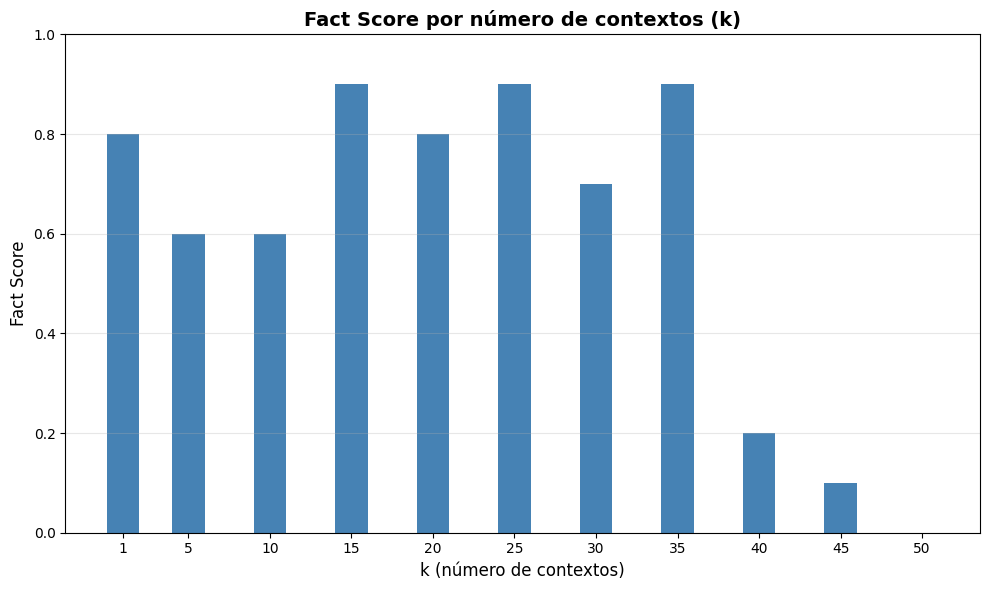

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(score_map.keys(), score_map.values(), color='steelblue', width=2)
plt.xlabel('k (número de contextos)', fontsize=12)
plt.ylabel('Fact Score', fontsize=12)
plt.title('Fact Score por número de contextos (k)', fontsize=14, fontweight='bold')
plt.xticks(list(score_map.keys()))
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
